## EDA по данным риелторской компании

В файле clients.csv предоставлена информация о клиентах риелторской компании США за один месяц. Вам необходимо как специалисту по Data Science сделать следующее:

- Провести разведочный анализ данных, посмотреть на датасет, есть ли пропуски - посмотреть на зависимости признаков
- Используя данные о выборке, постройте типичный портрет целевого клиента компании (пол, возраст, какой тип квартиры он приобретает, какова площадь в кв. м , каков средний чек, цель покупки, источник лида (погуглите что такое лид в маркетинге, за это отвечает колонка Source).

Таким образом после вашего анализа, я хочу увидеть описание нашего целевого клиента с соответствующими визуализациями. Ожидаю увидеть как минимум 5 графиков с комментариями. Отнеситесь к заданию достойно, представьте, что от Вашего отчета зависит принятие важного решения.

---

**Баллы могут быть снижены** за качество кода - старайтесь чтобы код был максимально лаконичным. Названия переменных (если они используются) должны отражать максимальную ее сущность.

**Комментарии по сдаче практического задания**:
1. Залить в репу на github в папку module_2/descriptive_stats
2. Ссылку на репо отправлять мне на почту alexadevv@gmail.com не позднее дедлайна.
3. Тема письма: Домашнее задание по модулю 2 <Фамилия Имя>
4. После дедлайна, неотправленные на почту задания, оцениваются максимум в 7 баллов.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.show_dimensions', False)
pd.set_option('display.max_columns', None)

# Знакомство с данными

In [2]:
data = pd.read_csv('clients.csv')

In [3]:
data.head()

,ID,Building,Year of sale,Month of sale,Type of property,Property number,Area (ft.),Price,Status,Customer ID,Entity,Name,Surname,Age at time of purchase,Age Interval,Y,M,D,Gender,Country,State,Purpose,Deal satisfaction,Mortgage,Source
0,1030,1,2005,11,Apartment,30,743.09,"$ 246,172.68",Sold,C0028,Individual,Madalyn,Mercer,19.0,18-25,1986.0,6.0,21.0,F,USA,California,Home,5,No,Website
1,1029,1,2005,10,Apartment,29,756.21,"$ 246,331.90",Sold,C0027,Individual,Lara,Carrillo,22.0,18-25,1983.0,2.0,24.0,F,USA,California,Home,5,No,Website
2,2002,2,2007,7,Apartment,2,587.28,"$ 209,280.91",Sold,C0112,Individual,Donavan,Flowers,22.0,18-25,1985.0,12.0,27.0,M,USA,California,Home,1,Yes,Client
3,2031,2,2007,12,Apartment,31,1604.75,"$ 452,667.01",Sold,C0160,Individual,Darien,Dorsey,22.0,18-25,1985.0,12.0,27.0,M,USA,California,Investment,3,Yes,Website
4,1049,1,2004,11,Apartment,49,1375.45,"$ 467,083.31",Sold,C0014,Individual,Alessandra,Perry,25.0,18-25,1979.0,5.0,15.0,F,USA,California,Home,4,No,Agency


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       195 non-null    int64  
 1   Building                 195 non-null    int64  
 2   Year of sale             195 non-null    int64  
 3   Month of sale            195 non-null    int64  
 4   Type of property         195 non-null    object 
 5   Property number          195 non-null    int64  
 6   Area (ft.)               195 non-null    float64
 7   Price                    195 non-null    object 
 8   Status                   195 non-null    object 
 9   Customer ID              195 non-null    object 
 10  Entity                   195 non-null    object 
 11  Name                     195 non-null    object 
 12  Surname                  195 non-null    object 
 13  Age at time of purchase  178 non-null    float64
 14  Age Interval             1

# Преобразование и чистка данных

Переименуем колонки для удобства:

In [5]:
data.columns = ['id', 'building', 'year_of_sale', 'month_of_sale', 'property_type', 'property_number', 'area', 'price', 'status', 'id_customer', 'entity', 'name', 'surname', 'purchase_age', 'age_interval', 'y', 'm', 'd', 'gender', 'country', 'state', 'purpose', 'satisfaction', 'mortgage', 'source']

Конвертируем стороковые значения стоимости в числовые:

In [6]:
def convert_currency(x):
    if isinstance(x, str):
        return int(float(x.replace('$', '').replace(',', '')))
    return x
data['price'] = data['price'].apply(convert_currency)

Заполним пустые значения для сделок где неизвестен штат, чтобы их можно было учитывать:

In [7]:
data['state'] = data['state'].fillna('Not defined')

Переведем площадь объектов в футах в квадратные метры:

In [8]:
data['area'] = data['area'] * 0.092903

In [9]:
data.describe()

,id,building,year_of_sale,month_of_sale,property_number,area,price,purchase_age,y,m,d,satisfaction
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,178.000000,178.000000,178.000000,178.000000,195.000000
mean,2591.425641,2.564103,2006.333333,7.271795,27.328205,83.600356,269434.076923,46.151685,1960.325843,6.752809,15.449438,3.605128
std,1244.617996,1.243434,1.072941,3.378674,14.830832,24.293164,80129.119076,12.841692,12.835575,3.450312,8.457285,1.363355
min,1002.000000,1.000000,2004.000000,1.000000,1.000000,38.156191,117564.000000,19.000000,1931.000000,1.000000,1.000000,1.000000
25%,2003.500000,2.000000,2006.000000,4.000000,15.000000,68.735214,212392.500000,37.000000,1950.250000,4.000000,8.000000,3.000000
50%,2054.000000,2.000000,2007.000000,8.000000,27.000000,72.973448,243052.000000,45.000000,1962.000000,6.000000,15.000000,4.000000
75%,3048.500000,3.000000,2007.000000,10.000000,39.000000,99.913460,308550.500000,55.000000,1969.750000,9.750000,23.750000,5.000000
max,5051.000000,5.000000,2010.000000,12.000000,59.000000,180.464078,529317.000000,76.000000,1986.000000,15.000000,31.000000,5.000000


# EDA

## 1. Зависимость стоимости от квадратного метра

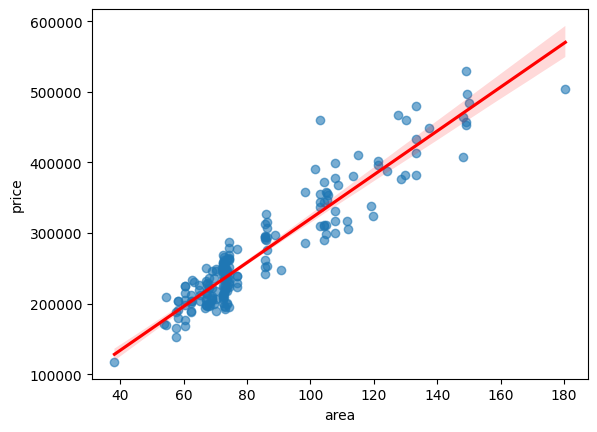

In [10]:
sns.regplot(
    data=data, 
    x='area', 
    y='price',
    line_kws={'color': 'red'},
    scatter_kws={'alpha': 0.6}
)
plt.show()

Наблюдается линейный рост цены в зависимости от площади объекта.

## 2. Демографический портрет

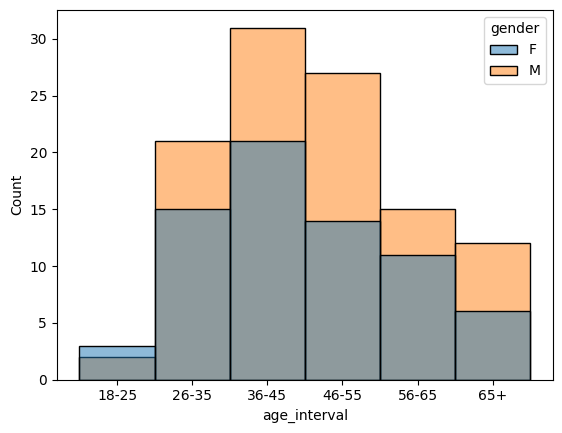

In [11]:
sns.histplot(data=data, x='age_interval', hue='gender')
plt.show()

В основном клиентами являются мужчины 36-55 лет.

## 3. Источники и ценность лидов

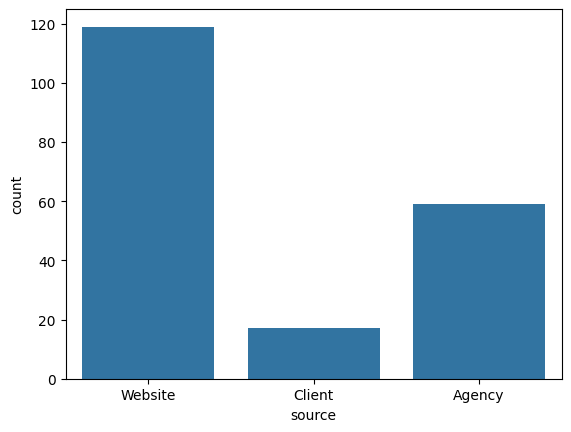

In [12]:
sns.countplot(data=data, x='source')
plt.show()

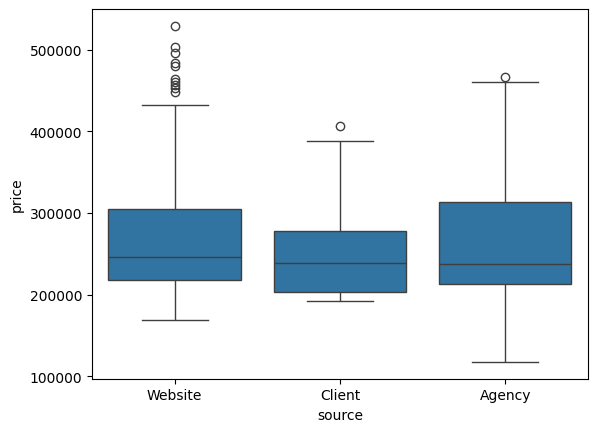

In [13]:
sns.boxplot(data=data, x='source', y='price')
plt.show()

Больше всего лидов приходит с сайта, средний чек не зависит от источника лида. Тем не менее сайт генерирует серьезное количество "китов".

## 4. Распределение типа собственности в зависимости от цели покупки

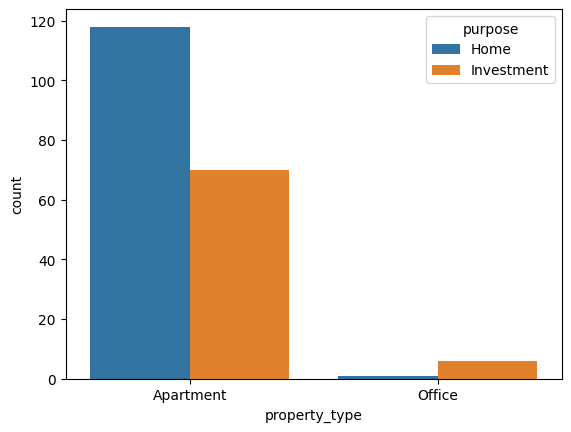

In [14]:
sns.countplot(data=data, x='property_type', hue='purpose')
plt.show()

In [15]:
apartment_prop = data[(data['purpose'] == 'Investment') & (data['property_type'] == 'Apartment')].shape[0] / data.shape[0]
print(f"Apartment share deals - {apartment_prop*100:.1f}%")

Apartment share deals - 35.9%


Основная доля сделок - продажа квартир. Значительная часть квартир (36%) покупается как инвестиция, можно использовать эти сделки для постпродажных предложений (поиск арендодателей, обслуживание).

## 5. Сезонность продаж

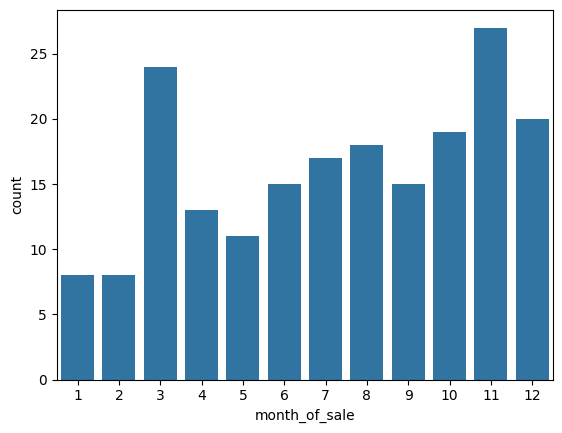

In [16]:
sns.countplot(data=data, x='month_of_sale')
plt.show()

Активность продаж нарастает в течении года. Сильно выделяетс март, возможно есть свзяь активности покупателей с началом весны и закрытием первого квартала.

## 6. Удовлетворенность сделкой в зависимости от направления

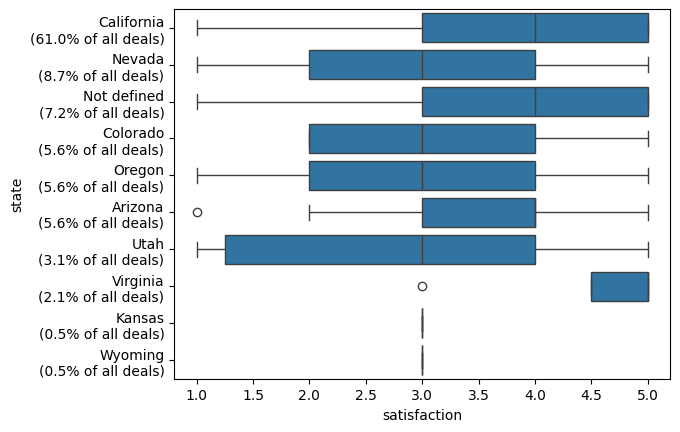

In [17]:
state_counts = data['state'].value_counts()
ax = sns.boxplot(
    data=data, 
    x='satisfaction', 
    y='state', 
    native_scale=True,
    order=state_counts.index
)
new_labels = []
for label in ax.get_yticklabels():
    new_labels.append(f"{label.get_text()}\n({state_counts[label.get_text()] / data.shape[0] * 100:.1f}% of all deals)")
              
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(new_labels)
plt.show()

На самом большом направлении - Калифорния (61%) в среднем лучший уровень удовлетворенности, тогда как на всех остальных направлениях уровень удовлетворенности ниже.